# Conv1D Autoencoder v3 — 6-Second Epoch Experiment

**Changes from v1:**
- Tighter bottleneck: 8ch × 96 = 768 values (~34× compression vs 26,112 input)
- Dropout(0.2) in encoder to reduce overfitting
- L1 regularization on bottleneck activations (sparsity)
- Batch size 32 (smaller = better gradient estimates)
- **6-second epochs (1536 samples)** — 3× longer context window than v2
- Validation split used for threshold selection; test split reserved for final eval

In [1]:
import os
import json
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import random
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import clear_output

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True

In [3]:
def iter_normal_batches(file_list, batch_size):
    """Yields batches of non-seizure epochs from .npz files, one file at a time."""
    for path in file_list:
        with np.load(path) as d:
            X = d['epochs'][d['labels'] == 0]
        if len(X) == 0:
            continue
        t = torch.tensor(X, dtype=torch.float32)
        loader = DataLoader(TensorDataset(t), batch_size=batch_size,shuffle=True, pin_memory=True, num_workers=0)
        for (batch,) in loader:
            yield batch
        del X, t, loader


def get_file_chunks(files, chunk_size=7):
    files = files.copy()
    while True:
        random.shuffle(files)
        for i in range(0, len(files), chunk_size):
            yield files[i:i+chunk_size]


def validate(model, val_files, batch_size, criterion):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in iter_normal_batches(val_files, batch_size):
            batch = batch.to(DEVICE, non_blocking=True)
            recon, _ = model(batch)
            total += criterion(recon, batch).item() * len(batch)
            n += len(batch)
    return total / n if n else float('inf')


def load_checkpoint(path, model, optimizer):
    if os.path.exists(path):
        ck = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ck['model'])
        optimizer.load_state_dict(ck['optim'])
        print(f"Resumed from epoch {ck['epoch']+1}")
        return ck['epoch']+1, ck['train_hist'], ck['val_hist'], ck['best_val']
    print("Starting fresh training.")
    return 0, [], [], float('inf')


def save_checkpoint(path, epoch, model, optimizer, train_hist, val_hist, best_val):
    torch.save({'epoch': epoch, 'model': model.state_dict(), 'optim': optimizer.state_dict(),
                'train_hist': train_hist, 'val_hist': val_hist, 'best_val': best_val}, path)


def plot_loss(train_hist, val_hist):
    clear_output(wait=True)
    plt.figure(figsize=(9, 4))
    plt.plot(train_hist, label='Train', color='steelblue')
    plt.plot(val_hist,   label='Valid', color='orange')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.title('Conv1D Autoencoder v3 — Training Loss')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


def train(model, optimizer, train_files, val_files, criterion, num_epochs, batch_size, checkpoint, best_model, l1_lambda):

    start, train_hist, val_hist, best_val = load_checkpoint(checkpoint, model, optimizer)

    chunk_gen = get_file_chunks(train_files, chunk_size=7)

    # Plot initial validation loss before training
    avg_val= validate(model, val_files, batch_size, criterion)
    train_hist.append(avg_val)
    val_hist.append(avg_val)
    plot_loss(train_hist, val_hist)
    print(f"Epoch [{0}/{num_epochs}] Val: {avg_val:.6f}")

    for epoch in range(start, num_epochs):
        model.train()
        epoch_loss, n = 0.0, 0

        chunck_files = next(chunk_gen)

        for batch in iter_normal_batches(chunck_files, batch_size):
            batch = batch.to(DEVICE, non_blocking=True)
            recon, z = model(batch)
            loss = criterion(recon, batch) + l1_lambda * z.abs().mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
            n += len(batch)

        avg_train = epoch_loss / n
        avg_val = validate(model, val_files, batch_size, criterion)

        train_hist.append(avg_train)
        val_hist.append(avg_val)

        if avg_val < best_val:
            best_val = avg_val
            torch.save(model.state_dict(), best_model)

        save_checkpoint(checkpoint, epoch, model, optimizer, train_hist, val_hist, best_val)
        plot_loss(train_hist, val_hist)
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train: {avg_train:.6f}  Val: {avg_val:.6f}")

    model.load_state_dict(torch.load(best_model, map_location=DEVICE))
    torch.save(model.state_dict(), "Models/ae_v3_final.pt")
    print("Training complete. Best weights restored.")
    return train_hist, val_hist

In [4]:
class Conv1DAutoencoder(torch.nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        # Encoder: (B, 17, 1536) → (B, 32, 768) → (B, 64, 384) → (B, 128, 192) → (B, 8, 96)
        self.enc1 = torch.nn.Conv1d(17,  32,  kernel_size=4, stride=2, padding=1)
        self.bn1  = torch.nn.BatchNorm1d(32)
        self.enc2 = torch.nn.Conv1d(32,  64,  kernel_size=4, stride=2, padding=1)
        self.bn2  = torch.nn.BatchNorm1d(64)
        self.enc3 = torch.nn.Conv1d(64,  128, kernel_size=4, stride=2, padding=1)
        self.bn3  = torch.nn.BatchNorm1d(128)
        self.enc4 = torch.nn.Conv1d(128, 8,   kernel_size=4, stride=2, padding=1)  # bottleneck

        # Decoder: (B, 8, 96) → (B, 128, 192) → (B, 64, 384) → (B, 32, 768) → (B, 17, 1536)
        self.dec1 = torch.nn.ConvTranspose1d(8,   128, kernel_size=4, stride=2, padding=1)
        self.bn4  = torch.nn.BatchNorm1d(128)
        self.dec2 = torch.nn.ConvTranspose1d(128, 64,  kernel_size=4, stride=2, padding=1)
        self.bn5  = torch.nn.BatchNorm1d(64)
        self.dec3 = torch.nn.ConvTranspose1d(64,  32,  kernel_size=4, stride=2, padding=1)
        self.bn6  = torch.nn.BatchNorm1d(32)
        self.dec4 = torch.nn.ConvTranspose1d(32,  17,  kernel_size=4, stride=2, padding=1)

        self.relu = torch.nn.ReLU()
        self.drop = torch.nn.Dropout(dropout)

    def forward(self, x):
        z = self.drop(self.relu(self.bn1(self.enc1(x))))
        z = self.drop(self.relu(self.bn2(self.enc2(z))))
        z = self.drop(self.relu(self.bn3(self.enc3(z))))
        z = self.enc4(z)

        out = self.relu(self.bn4(self.dec1(z)))
        out = self.relu(self.bn5(self.dec2(out)))
        out = self.relu(self.bn6(self.dec3(out)))
        out = self.dec4(out)
        return out, z


In [5]:
os.makedirs("Models", exist_ok=True)

BATCH_SIZE    = 512
NUM_EPOCHS    = 50
CHECKPOINT    = "Models/ae_v3_checkpoint.pt"
BEST_MODEL    = "Models/ae_v3_best.pt"
L1_LAMBDA = 1e-4
CRITERION = torch.nn.MSELoss()
MODEL = Conv1DAutoencoder(dropout=0.2)
OPTIMIZER = torch.optim.Adam(MODEL.parameters(), lr=0.001)
MODEL.to(DEVICE)

print(f"Using DEVICE: {DEVICE}")
print(MODEL)
print(f"\nParameters: {sum(p.numel() for p in MODEL.parameters()):,}")

Using DEVICE: cuda
Conv1DAutoencoder(
  (enc1): Conv1d(17, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc2): Conv1d(32, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc3): Conv1d(64, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc4): Conv1d(128, 8, kernel_size=(4,), stride=(2,), padding=(1,))
  (dec1): ConvTranspose1d(8, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec2): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (bn5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dec3): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1

In [6]:
train_files = sorted(glob.glob('data_v3/train/*.npz'))
val_files   = sorted(glob.glob('data_v3/valid/*.npz'))
test_files  = sorted(glob.glob('data_v3/test/*.npz'))

print(f"Train patients : {len(train_files)}")
print(f"Valid patients : {len(val_files)}")
print(f"Test  patients : {len(test_files)}")

Train patients : 18
Valid patients : 2
Test  patients : 3


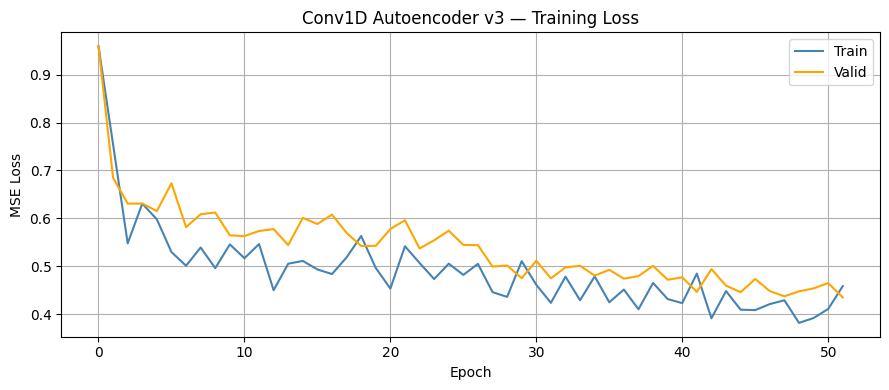

Epoch [50/50]  Train: 0.458594  Val: 0.434994
Training complete. Best weights restored.


In [7]:
train_hist, val_hist = train(MODEL, OPTIMIZER, train_files, val_files, CRITERION, NUM_EPOCHS, BATCH_SIZE, CHECKPOINT, BEST_MODEL, L1_LAMBDA)

Train normal  — mean MAE: 0.410378 | std: 0.190312
Optimal k=0.45  |  Threshold=0.496019


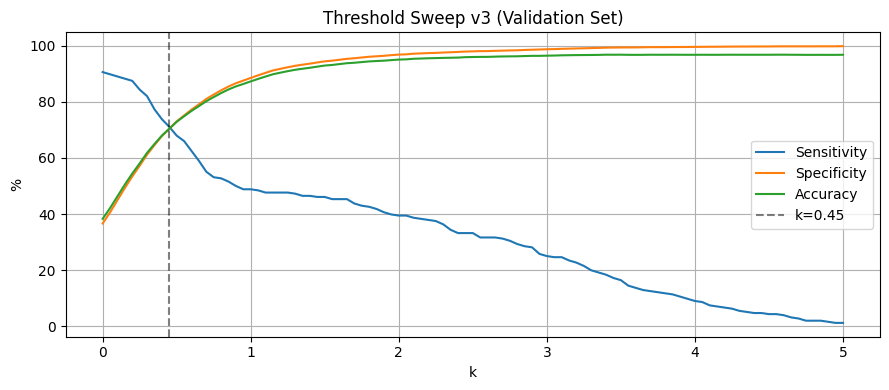

In [8]:
def collect_mae(model, file_list, both_classes=False):
    """Returns (mae_tensor, labels_array). If both_classes=False, only normal epochs."""
    model.eval()
    maes, labels = [], []
    with torch.no_grad():
        for path in file_list:
            with np.load(path) as d:
                X, y = d['epochs'], d['labels']
            if not both_classes:
                X = X[y == 0]
                y = y[y == 0]
            for i in range(0, len(X), 256):
                batch = torch.tensor(X[i:i+256], dtype=torch.float32).to(DEVICE)
                recon, _ = model(batch)
                maes.append(torch.mean(torch.abs(recon - batch), dim=(1, 2)).cpu())
            labels.extend(y)
    return torch.cat(maes), np.array(labels)


# Use VALID set for threshold tuning
train_mae, _      = collect_mae(MODEL, train_files, both_classes=False)
val_mae, y_val    = collect_mae(MODEL, val_files,   both_classes=True)

mean_mae = train_mae.mean().item()
std_mae  = train_mae.std().item()
print(f"Train normal  — mean MAE: {mean_mae:.6f} | std: {std_mae:.6f}")

best_k, best_diff = 1.0, float('inf')
sweep = []
for k in np.arange(0.0, 5.01, 0.05):
    t = mean_mae + k * std_mae
    preds = (val_mae.numpy() > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    sens = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    acc  = (tp + tn) / len(y_val) * 100
    sweep.append((k, t, sens, spec, acc))
    if abs(sens - spec) < best_diff:
        best_diff, best_k = abs(sens - spec), k

threshold = mean_mae + best_k * std_mae
print(f"Optimal k={best_k:.2f}  |  Threshold={threshold:.6f}")

with open('Models/ae_v3_threshold.json', 'w') as f:
    json.dump({'threshold': threshold, 'k': float(best_k),
               'mean_mae': mean_mae, 'std_mae': std_mae}, f, indent=2)

ks, sens_l, spec_l, acc_l = zip(*[(r[0],r[2],r[3],r[4]) for r in sweep])
plt.figure(figsize=(9, 4))
plt.plot(ks, sens_l, label='Sensitivity')
plt.plot(ks, spec_l, label='Specificity')
plt.plot(ks, acc_l,  label='Accuracy')
plt.axvline(best_k, color='k', linestyle='--', alpha=0.5, label=f'k={best_k:.2f}')
plt.xlabel('k'); plt.ylabel('%'); plt.title('Threshold Sweep v3 (Validation Set)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

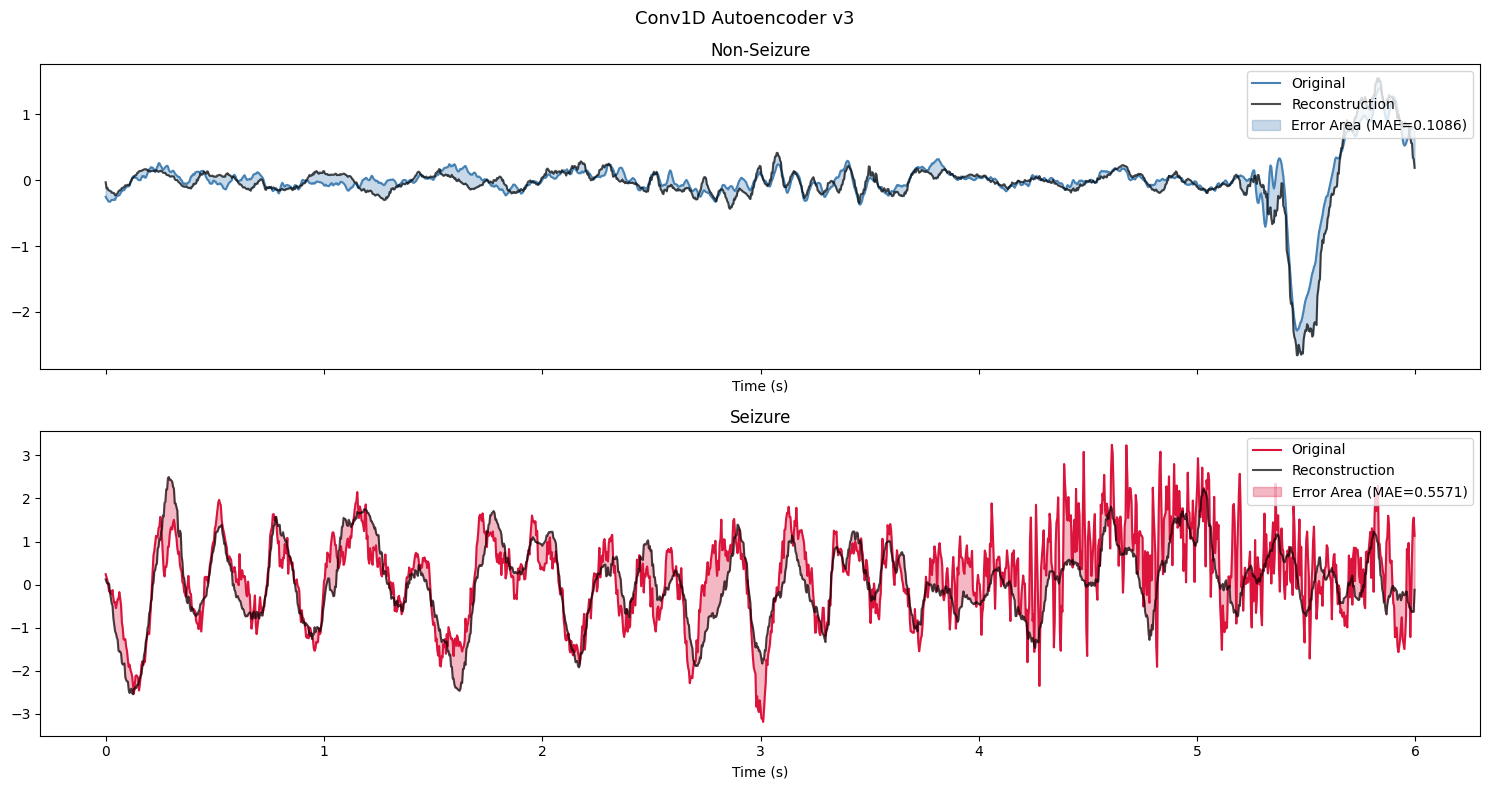

In [28]:
MODEL.eval()

src = test_files[0]
with np.load(src) as d:
    X_src, y_src = d['epochs'], d['labels']

normal_in  = torch.tensor(X_src[y_src == 0][3:4], dtype=torch.float32).to(DEVICE)
seizure_in = torch.tensor(X_src[y_src == 1][3:4], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    normal_out,  _ = MODEL(normal_in)
    seizure_out, _ = MODEL(seizure_in)

normal_in  = normal_in.cpu();  normal_out  = normal_out.cpu()
seizure_in = seizure_in.cpu(); seizure_out = seizure_out.cpu()

t_axis = np.arange(1536) / 256.0
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Conv1D Autoencoder v3', fontsize=13)

def plot_stacked(ax, orig, recon, color, label):
    err = np.abs(recon - orig)

    ax.plot(t_axis, orig, color=color, label='Original')
    ax.plot(t_axis, recon, color='black', alpha=0.7, label='Reconstruction')
    
    ax.fill_between(t_axis, orig, recon, color=color, alpha=0.3, label=f'Error Area (MAE={err.mean():.4f})')
    
    ax.set_title(label)
    ax.set_xlabel('Time (s)')
    ax.legend(loc='upper right')

plot_stacked(axes[0], normal_in[0,0].numpy(), normal_out[0,0].numpy(), 'steelblue', 'Non-Seizure')
plot_stacked(axes[1], seizure_in[0,0].numpy(), seizure_out[0,0].numpy(), 'crimson', 'Seizure')

plt.tight_layout()
plt.show()

In [ ]:
def metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return pd.DataFrame([{
        'Sensitivity': round(tp / (tp + fn) * 100, 1) if (tp + fn) > 0 else 0,
        'Specificity': round(tn / (tn + fp) * 100, 1) if (tn + fp) > 0 else 0,
        'Accuracy':    round((tp + tn) / len(y_true) * 100, 1),
        'F1 Score':    round(2*tp/(2*tp+fp+fn)*100, 1) if (2*tp+fp+fn) else 0,
    }])


test_mae, y_test = collect_mae(MODEL, test_files, both_classes=True)

y_pred = (test_mae.numpy() > threshold).astype(int)
print(f"Threshold: {threshold:.6f}  (k={best_k:.2f})")
print(f"Test — normal: {(y_test==0).sum()}  seizure: {(y_test==1).sum()}")
display(metrics(y_test, y_pred).style.hide(axis='index'))

Threshold: 0.496019  (k=0.45)
Test — normal: 13907  seizure: 492


Sensitivity,Specificity,Accuracy,F1 Score
92.700000,85.400000,85.600000,30.600000


## Patient-Specific Calibration

Fine-tune the globally trained model on each **test patient's own non-seizure
epochs** before evaluating. This personalises the reconstruction baseline to
individual EEG morphology without ever using seizure labels.

| Step | Data used | Purpose |
|------|-----------|---------|
| Fine-tune | Patient's normal epochs (test split) | Adapt weights to individual |
| Threshold | Patient's normal MAE after fine-tune | Re-anchor mean+k·std |
| Evaluate  | All patient epochs (normal + seizure) | Measure detection quality |

The global `k` from the validation sweep is reused — seizure labels are never seen.

In [ ]:
import copy

FINETUNE_LR     = 1e-4
FINETUNE_EPOCHS = 10
FINETUNE_WD     = 1e-5

def finetune_patient(base_model, normal_epochs, lr=FINETUNE_LR, epochs=FINETUNE_EPOCHS, batch_size=BATCH_SIZE, criterion=CRITERION):
    """Deep-copy the global model and fine-tune on one patient's normal data."""
    pt_model  = copy.deepcopy(base_model)
    pt_optim  = torch.optim.Adam(pt_model.parameters(), lr=lr, weight_decay=FINETUNE_WD)
    t         = torch.tensor(normal_epochs, dtype=torch.float32)
    loader    = DataLoader(TensorDataset(t), batch_size=batch_size, shuffle=True, drop_last=False)

    pt_model.train()
    for _ in range(epochs):
        for (batch,) in loader:
            batch = batch.to(DEVICE, non_blocking=True)
            recon, z = pt_model(batch)
            loss = criterion(recon, batch) + L1_LAMBDA * z.abs().mean()
            pt_optim.zero_grad()
            loss.backward()
            pt_optim.step()

    pt_model.eval()
    return pt_model


def patient_mae(mdl, X):
    """Compute per-epoch MAE for an ndarray X using model mdl."""
    maes = []
    with torch.no_grad():
        for i in range(0, len(X), 256):
            batch = torch.tensor(X[i:i+256], dtype=torch.float32).to(DEVICE)
            recon, _ = mdl(batch)
            maes.append(torch.mean(torch.abs(recon - batch), dim=(1, 2)).cpu())
    return torch.cat(maes).numpy()


# ── Per-patient evaluation ─────────────────────────────────────────────────────
rows_global, rows_ft = [], []

MODEL.eval()
for path in test_files:
    pid = os.path.basename(path).replace('.npz', '')

    with np.load(path) as d:
        X, y = d['epochs'], d['labels']

    idx_normal = np.where(y == 0)[0]
    idx_seizure = np.where(y == 1)[0]

    idx_normal_sampled = np.random.choice(idx_normal, size=len(idx_seizure), replace=False)
    idx_balanced = np.concatenate([idx_normal_sampled, idx_seizure])
    np.random.shuffle(idx_balanced)

    normal_X  = X[idx_normal]
    balanced_X = X[idx_balanced]
    balanced_y = y[idx_balanced]

    n_normal  = len(idx_normal_sampled)
    n_seizure = len(idx_seizure)

    # ── Global model ──────────────────────────────────────────────────────────
    g_mae  = patient_mae(MODEL, balanced_X)
    g_pred = (g_mae > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(balanced_y, g_pred).ravel()
    rows_global.append({
        'Patient':     pid,
        'Normal':      n_normal,
        'Seizure':     n_seizure,
        'Sensitivity': round(tp/(tp+fn)*100, 1) if (tp+fn) else 0,
        'Specificity': round(tn/(tn+fp)*100, 1) if (tn+fp) else 0,
        'Accuracy':    round((tp+tn)/len(balanced_y)*100, 1),
        'F1 Score':    round(2*tp/(2*tp+fp+fn)*100, 1) if (2*tp+fp+fn) else 0,
    })

    # ── Fine-tuned model ──────────────────────────────────────────────────────
    ft_model   = finetune_patient(MODEL, normal_X)
    ft_mae_all = patient_mae(ft_model, balanced_X)

    # Recompute threshold using this patient's own normal reconstruction error
    ft_normal_mae = patient_mae(ft_model, balanced_X)

    ft_pred = (ft_mae_all > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(balanced_y, ft_pred).ravel()
    rows_ft.append({
        'Patient':     pid,
        'Normal':      n_normal,
        'Seizure':     n_seizure,
        'Sensitivity': round(tp/(tp+fn)*100, 1) if (tp+fn) else 0,
        'Specificity': round(tn/(tn+fp)*100, 1) if (tn+fp) else 0,
        'Accuracy':    round((tp+tn)/len(balanced_y)*100, 1),
        'F1 Score':    round(2*tp/(2*tp+fp+fn)*100, 1) if (2*tp+fp+fn) else 0,
    })

# ── Summary tables ─────────────────────────────────────────────────────────────
print("Global model")
df_global = pd.DataFrame(rows_global).set_index('Patient')
df_global.loc['Average'] = df_global.mean().round(2)
display(df_global)

print("After patient-specific fine-tuning")
df_ft = pd.DataFrame(rows_ft).set_index('Patient')
df_ft.loc['Average'] = df_ft.mean().round(2)
display(df_ft)

Global model


,Normal,Seizure,Sensitivity,Specificity,Accuracy,F1 Score
Patient,,,,,,
chb07,104.0,104.0,99.00,92.30,95.70,95.80
chb08,300.0,300.0,88.30,87.00,87.70,87.70
chb09,88.0,88.0,100.00,71.60,85.80,87.60
Average,164.0,164.0,95.77,83.63,89.73,90.37


After patient-specific fine-tuning


,Normal,Seizure,Sensitivity,Specificity,Accuracy,F1 Score
Patient,,,,,,
chb07,104.0,104.0,99.00,93.30,96.20,96.3
chb08,300.0,300.0,84.00,89.30,86.70,86.3
chb09,88.0,88.0,100.00,75.00,87.50,88.9
Average,164.0,164.0,94.33,85.87,90.13,90.5
